# Surface Crack Detection using CNN

# Model Training

## Objectives

- Load the training dataset
- Train the CNN model
- Visualize training performance
- Save the trained model

In [23]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)
import matplotlib.pyplot as plt
import os

In [24]:
IMAGE_SIZE = (120,120)
BATCH_SIZE = 32
EPOCHS = 15

dataset_path = "../data"

In [25]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 40000 files belonging to 2 classes.
Using 32000 files for training.


In [26]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 40000 files belonging to 2 classes.
Using 8000 files for validation.


In [27]:
normalization_layer = layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [28]:
model = models.Sequential([

    layers.Input(shape=(120,120,3)),

    layers.Conv2D(32,(3,3),activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(1,activation="sigmoid")

])

In [29]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [30]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath="../models/best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

In [31]:
import os

model_path = "../models/crack_detection_model.keras"

if os.path.exists(model_path):
    print("Loading previously saved model...")
    model = tf.keras.models.load_model(model_path)
else:
    print("No saved model found. Training a new model.")

No saved model found. Training a new model.


In [32]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/15


1000/1000 [==============================] - ETA: 0s - loss: 0.0803 - accuracy: 0.9740
Epoch 1: val_accuracy improved from -inf to 0.98700, saving model to ../models\best_model.h5
1000/1000 [==============================] - 338s 337ms/step - loss: 0.0803 - accuracy: 0.9740 - val_loss: 0.0395 - val_accuracy: 0.9870
Epoch 2/15


c:\Users\vinit\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1000/1000 [==============================] - ETA: 0s - loss: 0.0351 - accuracy: 0.9889
Epoch 2: val_accuracy improved from 0.98700 to 0.99150, saving model to ../models\best_model.h5
1000/1000 [==============================] - 387s 387ms/step - loss: 0.0351 - accuracy: 0.9889 - val_loss: 0.0225 - val_accuracy: 0.9915
Epoch 3/15
1000/1000 [==============================] - ETA: 0s - loss: 0.0293 - accuracy: 0.9917
Epoch 3: val_accuracy improved from 0.99150 to 0.99450, saving model to ../models\best_model.h5
1000/1000 [==============================] - 445s 445ms/step - loss: 0.0293 - accuracy: 0.9917 - val_loss: 0.0172 - val_accuracy: 0.9945
Epoch 4/15
1000/1000 [==============================] - ETA: 0s - loss: 0.0202 - accuracy: 0.9939
Epoch 4: val_accuracy did not improve from 0.99450
1000/1000 [==============================] - 405s 405ms/step - loss: 0.0202 - accuracy: 0.9939 - val_loss: 0.0243 - val_accuracy: 0.9929
Epoch 5/15
1000/1000 [==============================] - ETA: 0s

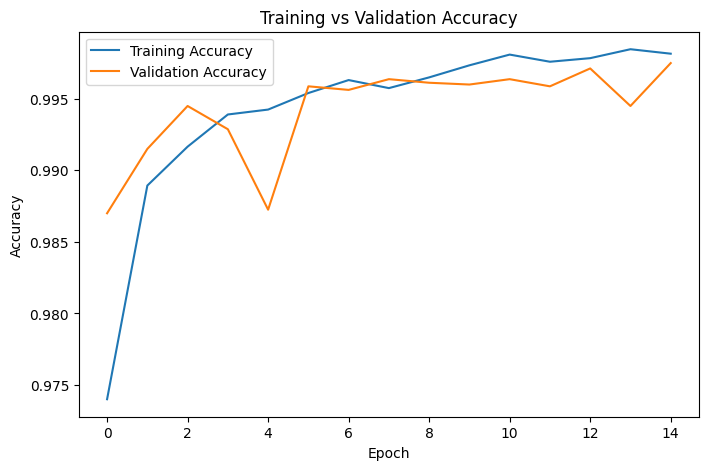

In [33]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

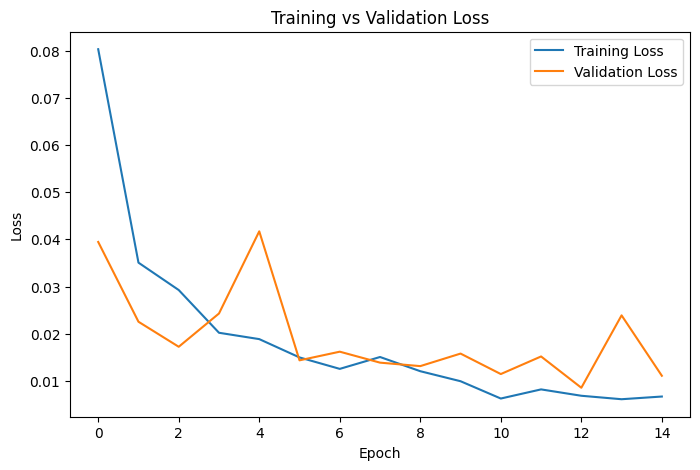

In [34]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [35]:
loss, accuracy = model.evaluate(validation_dataset)

print(f"Validation Accuracy: {accuracy:.4f}")

250/250 [==============================] - 54s 214ms/step - loss: 0.0111 - accuracy: 0.9975
Validation Accuracy: 0.9975


In [36]:
best_model = tf.keras.models.load_model("../models/best_model.h5")
best_model.save("../models/crack_detection_model.keras")

# Summary

Completed:

- Loaded training and validation datasets
- Trained CNN model
- Visualized accuracy and loss
- Evaluated model
- Saved trained model